In [9]:
# Add target col

import pandas as pd
import nba_api_module as nbpim

df_input = pd.read_csv("data/ml_ready_2024_25.csv")

# Drop star injury
df_input.drop(columns=['home_missing_starters', 'away_missing_starters'], inplace=True)


gid = f"00{df_input.loc[0, "game_id"]}"

season_log = nbpim.get_season_game_log("2024-25")
season_log_home = season_log[season_log['MATCHUP'].str.contains(' vs. ')]
season_log_home['is_home_win'] = season_log_home['WL'].apply(lambda x: 1 if x == 'W' else 0)
season_log_home.rename(columns={'GAME_ID': 'game_id'}, inplace=True)
season_log_home.game_id = season_log_home.game_id.astype(int)

df_input = pd.merge(df_input, season_log_home[['game_id', 'is_home_win']],
                    on="game_id", how="left")

print(df_input.sample(5))
print(df_input.columns)

      game_id  home_ORtg  away_ORtg  home_DRtg  away_DRtg  home_NET_rtg  \
487  22400488  99.700672  84.073894  90.957111  88.441171      8.743561   
451  22400452  95.035823  91.175603  84.610709  88.387046     10.425115   
99   22400100  95.035823  89.654286  84.610709  91.511610     10.425115   
357  22400358  95.847321  86.110490  95.180133  90.540750      0.667188   
461  22400462  93.110706  91.539438  92.501856  94.739900      0.608851   

     away_NET_rtg   home_PACE   away_PACE  home_TS%  ...  home_rest_days  \
487     -4.367277  123.053519  126.376923  0.615990  ...               5   
451      2.788557  123.988333  122.311071  0.582650  ...               4   
99      -1.857324  123.988333  130.197091  0.582650  ...               4   
357     -4.430260  118.176731  126.813818  0.592093  ...               5   
461     -3.200462  125.422545  119.195741  0.577500  ...               4   

     home_recent_form10  home_recent_form5  home_recent_form3  \
487                 0.8    

C:\Users\Adam\AppData\Local\Temp\ipykernel_7872\1038124081.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  season_log_home['is_home_win'] = season_log_home['WL'].apply(lambda x: 1 if x == 'W' else 0)
C:\Users\Adam\AppData\Local\Temp\ipykernel_7872\1038124081.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  season_log_home.rename(columns={'GAME_ID': 'game_id'}, inplace=True)
C:\Users\Adam\AppData\Local\Temp\ipykernel_7872\1038124081.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

Új differenciális features hozzáadva. Új shape: (550, 62)

Új feature-ök száma: 20

=== ERŐSEN KORRELÁLÓ FEATURE PÁROK (|corr| > 0.85) ===

     Feature 1      Feature 2  Correlation
home_rest_days away_rest_days     0.999458
       TS_diff       EFG_diff     0.992266
      home_TS%      home_EFG%     0.991397
      away_TS%      away_EFG%     0.990996
     ORtg_diff        TS_diff     0.954334
     home_ORtg       home_TS%     0.954181
     ORtg_diff       EFG_diff     0.951286
     home_ORtg      home_EFG%     0.951124
     away_ORtg       away_TS%     0.948221
     away_ORtg      away_EFG%     0.946333

=== TOP 15 FEATURE CORRELATION A TARGET-TEL ===

NET_rtg_diff           0.421425
recent_form10_diff     0.323449
away_NET_rtg           0.319516
recent_form5_diff      0.307741
home_NET_rtg           0.306267
turnover_diff          0.282006
ORtg_diff              0.278071
EFG_diff               0.270192
TS_diff                0.267419
recent_form3_diff      0.263959
home_recent_form1

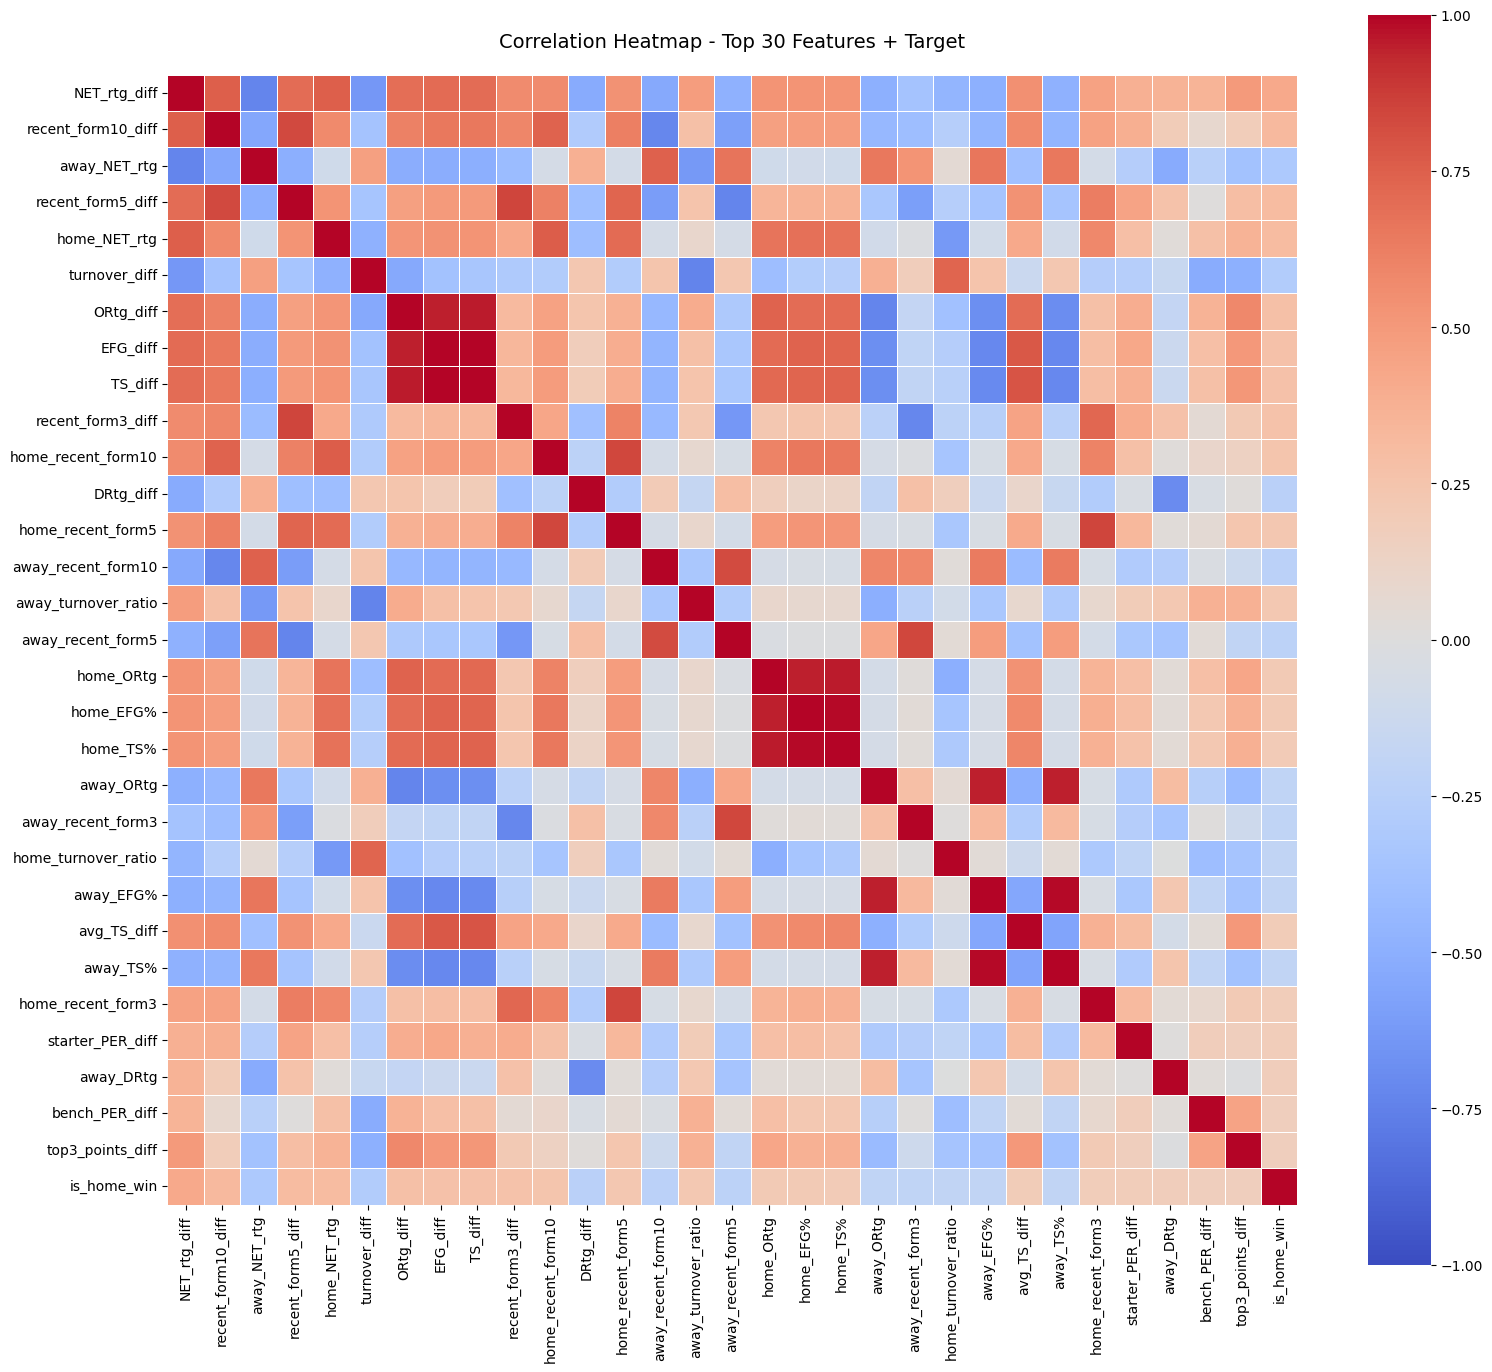


=== AJÁNLÁS: REDUNDÁNS FEATURES ELTÁVOLÍTÁSA ===

Javasolt eltávolítandó features (7 db):
  - TS_diff
  - home_rest_days
  - home_TS%
  - away_EFG%
  - away_TS%
  - EFG_diff
  - home_EFG%

=== EREDMÉNY ===
Eredeti feature-ök száma: 42
Új differenciális features: 20
Összes feature most: 62

Használd a 'df' dataframe-et a továbbiakban a bővített feature-ökkel!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------------
# 1) DIFFERENCIÁLIS FEATURES HOZZÁADÁSA
# -------------------------------------------------------------------------

df = df_input.copy()

# Offensive/Defensive Rating különbségek
df['ORtg_diff'] = df['home_ORtg'] - df['away_ORtg']
df['DRtg_diff'] = df['home_DRtg'] - df['away_DRtg']
df['NET_rtg_diff'] = df['home_NET_rtg'] - df['away_NET_rtg']

# Pace különbség
df['PACE_diff'] = df['home_PACE'] - df['away_PACE']

# Hatékonyság különbségek
df['TS_diff'] = df['home_TS%'] - df['away_TS%']
df['EFG_diff'] = df['home_EFG%'] - df['away_EFG%']
df['AST_ratio_diff'] = df['home_AST_ratio'] - df['away_AST_ratio']
df['OREB_diff'] = df['home_OREB%'] - df['away_OREB%']
df['turnover_diff'] = df['home_turnover_ratio'] - df['away_turnover_ratio']

# Játékos minőség különbségek
df['starter_PER_diff'] = df['home_starter_avg_PER'] - df['away_starter_avg_PER']
df['bench_PER_diff'] = df['home_bench_avg_PER'] - df['away_bench_avg_PER']
df['star_usage_diff'] = df['home_star_usage'] - df['away_star_usage']
df['avg_TS_diff'] = df['home_avg_TS'] - df['away_avg_TS']
df['top3_points_diff'] = df['home_top3_points_avg'] - df['away_top3_points_avg']

# Pihenés és forma különbségek
df['rest_days_diff'] = df['home_rest_days'] - df['away_rest_days']
df['recent_form10_diff'] = df['home_recent_form10'] - df['away_recent_form10']
df['recent_form5_diff'] = df['home_recent_form5'] - df['away_recent_form5']
df['recent_form3_diff'] = df['home_recent_form3'] - df['away_recent_form3']

# Sérülés különbség
df['injury_count_diff'] = df['home_injury_count'] - df['away_injury_count']

# Back-to-back advantage (1 ha csak away, -1 ha csak home, 0 ha mindkettő vagy egyik sem)
df['b2b_advantage'] = df['away_is_back_to_back'].astype(int) - df['home_is_back_to_back'].astype(int)

print(f"Új differenciális features hozzáadva. Új shape: {df.shape}")
print(f"\nÚj feature-ök száma: {len([col for col in df.columns if 'diff' in col or 'advantage' in col])}")

# -------------------------------------------------------------------------
# 2) CORRELATION VIZSGÁLAT - CSAK NUMERIKUS FEATURE-ÖK
# -------------------------------------------------------------------------

# Exclude target és ID
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'is_home_win' in numeric_cols:
    numeric_cols.remove('is_home_win')
if 'game_id' in numeric_cols:
    numeric_cols.remove('game_id')

# Correlation matrix
corr_matrix = df[numeric_cols].corr()

# Erősen korreláló párok keresése (|corr| > 0.85, de nem önmagával)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"\n=== ERŐSEN KORRELÁLÓ FEATURE PÁROK (|corr| > 0.85) ===\n")
if high_corr_pairs:
    corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', 
                                                          key=abs, 
                                                          ascending=False)
    print(corr_df.to_string(index=False))
else:
    print("Nincs erősen korreláló feature pár (|corr| > 0.85)")

# -------------------------------------------------------------------------
# 3) CORRELATION HEATMAP (TOP 30 FEATURE TARGET-TEL)
# -------------------------------------------------------------------------

# Correlation a target változóval
target_corr = df[numeric_cols].corrwith(df['is_home_win']).abs().sort_values(ascending=False)

print(f"\n=== TOP 15 FEATURE CORRELATION A TARGET-TEL ===\n")
print(target_corr.head(15))

# Vizualizáció: top 30 feature heatmap
top_features = target_corr.head(30).index.tolist()
top_features.append('is_home_win')

plt.figure(figsize=(16, 14))
sns.heatmap(df[top_features].corr(), 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap - Top 30 Features + Target', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 4) AJÁNLÁSOK REDUNDÁNS FEATURES-ÖK ELTÁVOLÍTÁSÁRA
# -------------------------------------------------------------------------

print(f"\n=== AJÁNLÁS: REDUNDÁNS FEATURES ELTÁVOLÍTÁSA ===\n")

features_to_remove = []
for pair in high_corr_pairs:
    feat1, feat2 = pair['Feature 1'], pair['Feature 2']
    # Tartsd meg azt amelyik jobban korrelál a target-tel
    corr1 = abs(df[feat1].corr(df['is_home_win']))
    corr2 = abs(df[feat2].corr(df['is_home_win']))
    
    if corr1 > corr2:
        features_to_remove.append(feat2)
    else:
        features_to_remove.append(feat1)

features_to_remove = list(set(features_to_remove))

if features_to_remove:
    print(f"Javasolt eltávolítandó features ({len(features_to_remove)} db):")
    for feat in features_to_remove:
        print(f"  - {feat}")
else:
    print("Nincs javasolt eltávolítandó feature.")

# -------------------------------------------------------------------------
# 5) UPDATED DATAFRAME EXPORT
# -------------------------------------------------------------------------

print(f"\n=== EREDMÉNY ===")
print(f"Eredeti feature-ök száma: {len(df_input.columns)}")
print(f"Új differenciális features: {len([col for col in df.columns if 'diff' in col or 'advantage' in col])}")
print(f"Összes feature most: {len(df.columns)}")
print(f"\nHasználd a 'df' dataframe-et a továbbiakban a bővített feature-ökkel!")

# Használható változó
df_enhanced = df.copy()

Dataset méret: (549, 60)
Features száma: 60

=== PCA VARIANCE ANALÍZIS ===
95% variance magyarázatához szükséges komponensek: 22/60
90% variance magyarázatához szükséges komponensek: 17/60


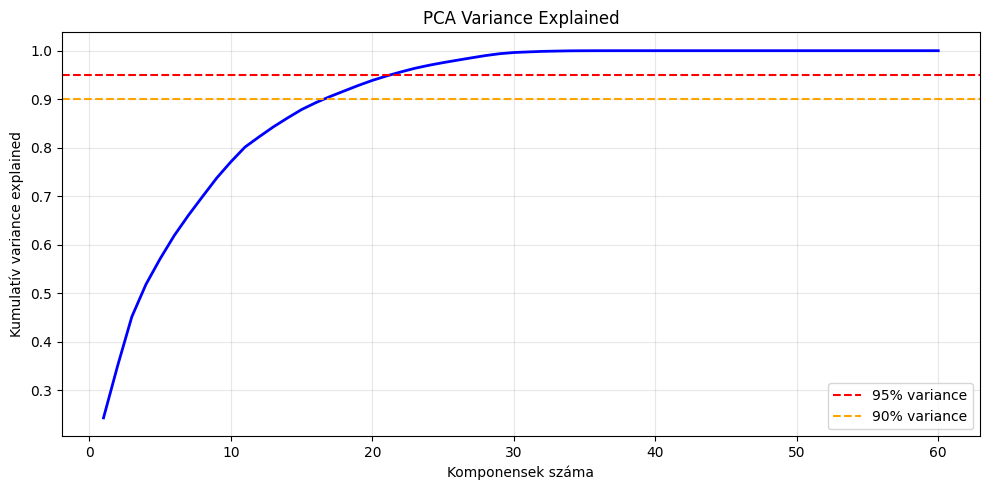


=== TIME-SERIES CV ===
Splits száma: 3
Split 1: Train=222 samples, Test=109 samples
Split 2: Train=331 samples, Test=109 samples
Split 3: Train=440 samples, Test=109 samples

=== MODELLEK KIÉRTÉKELÉSE TIME-SERIES CV-VEL ===

--- Standard Features ---

Futtatás: Logistic Regression...
Futtatás: Random Forest...
Futtatás: Gradient Boosting...
Futtatás: XGBoost (Tuned)...


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:26:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:26:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:26:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- PCA Features (90% variance) ---

Futtatás: Logistic Regression + PCA...
Futtatás: Random Forest + PCA...
Futtatás: XGBoost (Tuned) + PCA...


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:26:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:26:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:26:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== VÉGLEGES EREDMÉNYEK ===

                           Accuracy_mean  Accuracy_std  AUC_mean   AUC_std  LogLoss_mean  LogLoss_std
Random Forest + PCA             0.654434      0.049876  0.708051  0.031901      0.629468     0.039002
XGBoost (Tuned) + PCA           0.648318      0.011442  0.693340  0.026265      0.673737     0.046045
Logistic Regression + PCA       0.629969      0.026307  0.683587  0.029332      0.656921     0.036520
Logistic Regression             0.623853      0.014982  0.683322  0.015123      0.674541     0.020838
Random Forest                   0.642202      0.059456  0.682161  0.024942      0.654363     0.029713
XGBoost (Tuned)                 0.636086      0.037703  0.675904  0.013831      0.699955     0.036876
Gradient Boosting               0.611621      0.036951  0.660189  0.018793      0.767179     0.056118

🏆 LEGJOBB MODELL: Random Forest + PCA
   AUC: 0.7081 (±0.0319)
   Accuracy: 0.6544 (±0.0499)
   LogLoss: 0.6295 (±0.0390)


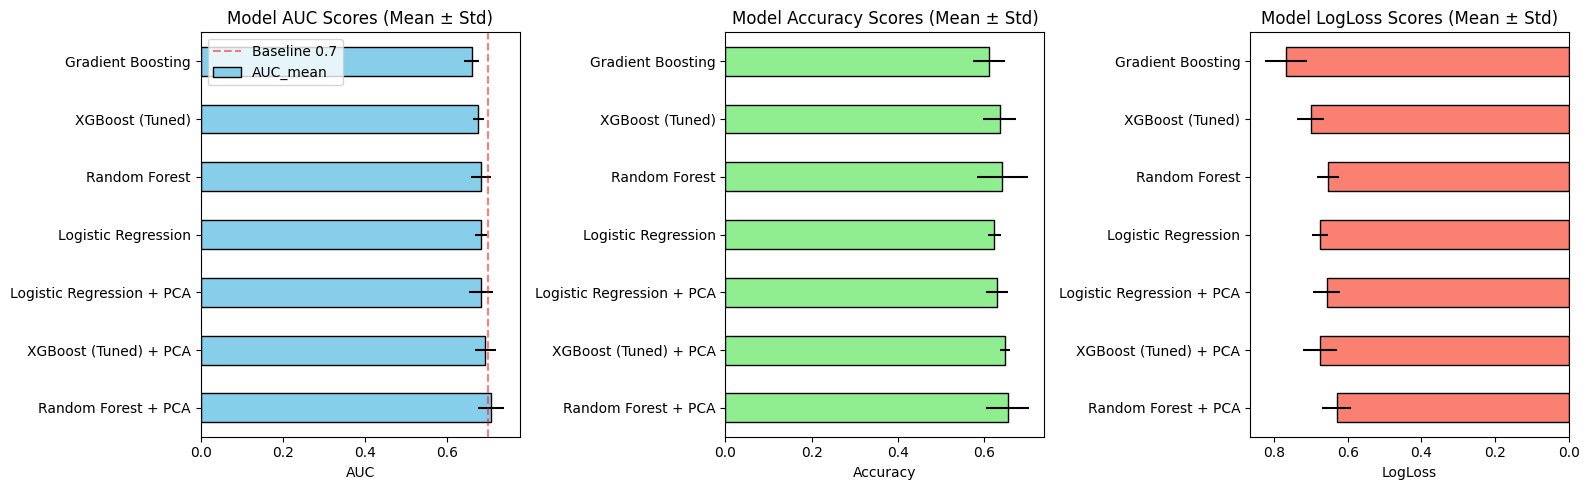

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1) ADATOK ELŐKÉSZÍTÉSE
# -------------------------------------------------------------------------

df = df_enhanced.copy()
df.dropna(subset=["is_home_win"], inplace=True)

# Célváltozó
y = df["is_home_win"]

# Features (game_id és target nélkül)
X = df.drop(columns=["is_home_win", "game_id"])

print(f"Dataset méret: {X.shape}")
print(f"Features száma: {X.shape[1]}")

# -------------------------------------------------------------------------
# 2) PCA VIZSGÁLAT - Variance Explained
# -------------------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA a teljes adatra (csak exploratory)
pca_full = PCA()
pca_full.fit(X_scaled)

# Variance explained
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Hány komponens kell 95% variance-hez?
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_components_90 = np.argmax(cumsum_variance >= 0.90) + 1

print(f"\n=== PCA VARIANCE ANALÍZIS ===")
print(f"95% variance magyarázatához szükséges komponensek: {n_components_95}/{X.shape[1]}")
print(f"90% variance magyarázatához szükséges komponensek: {n_components_90}/{X.shape[1]}")

# Vizualizáció
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 'b-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
plt.xlabel('Komponensek száma')
plt.ylabel('Kumulatív variance explained')
plt.title('PCA Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 3) TIME-SERIES CROSS-VALIDATION SETUP
# -------------------------------------------------------------------------

def time_series_cv_split(X, y, n_splits=5, test_size=0.2):
    """
    Time-series cross-validation: rolling window approach
    """
    n_samples = len(X)
    test_size_samples = int(n_samples * test_size)
    step = test_size_samples
    
    splits = []
    for i in range(n_splits):
        test_end = n_samples - (n_splits - 1 - i) * step
        test_start = test_end - test_size_samples
        train_end = test_start
        
        if train_end < int(n_samples * 0.3):  # Min 30% training data
            continue
            
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(test_start, test_end)
        
        splits.append((train_idx, test_idx))
    
    return splits

# CV splits generálása
cv_splits = time_series_cv_split(X, y, n_splits=5)
print(f"\n=== TIME-SERIES CV ===")
print(f"Splits száma: {len(cv_splits)}")
for i, (train_idx, test_idx) in enumerate(cv_splits):
    print(f"Split {i+1}: Train={len(train_idx)} samples, Test={len(test_idx)} samples")

# -------------------------------------------------------------------------
# 4) MODELLEK DEFINIÁLÁSA
# -------------------------------------------------------------------------

# Regularizált XGBoost
xgb_tuned = XGBClassifier(
    n_estimators=200,          # Csökkentve 400-ról
    learning_rate=0.05,        # Növelve 0.03-ról (kevesebb iteráció)
    max_depth=4,               # Csökkentve 6-ról (egyszerűbb fák)
    min_child_weight=5,        # Növelve 1-ről (overfit csökkentés)
    gamma=1.0,                 # Új: pruning threshold
    subsample=0.8,             # Csökkentve 0.9-ről
    colsample_bytree=0.8,      # Csökkentve 0.9-ről
    reg_alpha=0.5,             # L1 regularization
    reg_lambda=2.0,            # L2 regularization (növelve 1-ről)
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, 
        max_depth=8, 
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost (Tuned)": xgb_tuned
}

# PCA modellek (90% variance)
models_pca = {
    "Logistic Regression + PCA": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest + PCA": RandomForestClassifier(
        n_estimators=300, 
        max_depth=8, 
        random_state=42
    ),
    "XGBoost (Tuned) + PCA": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        gamma=1.0,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42
    )
}

# -------------------------------------------------------------------------
# 5) MODELLEK KIÉRTÉKELÉSE TIME-SERIES CV-VEL
# -------------------------------------------------------------------------

def evaluate_model_cv(model, X, y, cv_splits, use_pca=False, n_components=None):
    """
    Modell kiértékelése time-series CV-vel
    """
    accuracies = []
    aucs = []
    log_losses = []
    
    for train_idx, test_idx in cv_splits:
        X_train_fold = X[train_idx]
        X_test_fold = X[test_idx]
        y_train_fold = y.iloc[train_idx]
        y_test_fold = y.iloc[test_idx]
        
        # Scaling
        scaler_fold = StandardScaler()
        X_train_scaled = scaler_fold.fit_transform(X_train_fold)
        X_test_scaled = scaler_fold.transform(X_test_fold)
        
        # PCA ha kell
        if use_pca and n_components:
            pca = PCA(n_components=n_components)
            X_train_final = pca.fit_transform(X_train_scaled)
            X_test_final = pca.transform(X_test_scaled)
        else:
            # Logistic Regression scaled, mások nem
            if "Logistic" in str(type(model).__name__):
                X_train_final = X_train_scaled
                X_test_final = X_test_scaled
            else:
                X_train_final = X_train_fold
                X_test_final = X_test_fold
        
        # Training
        model.fit(X_train_final, y_train_fold)
        
        # Prediction
        pred_proba = model.predict_proba(X_test_final)[:, 1]
        preds = (pred_proba > 0.5).astype(int)
        
        # Metrics
        accuracies.append(accuracy_score(y_test_fold, preds))
        aucs.append(roc_auc_score(y_test_fold, pred_proba))
        log_losses.append(log_loss(y_test_fold, pred_proba))
    
    return {
        "Accuracy_mean": np.mean(accuracies),
        "Accuracy_std": np.std(accuracies),
        "AUC_mean": np.mean(aucs),
        "AUC_std": np.std(aucs),
        "LogLoss_mean": np.mean(log_losses),
        "LogLoss_std": np.std(log_losses)
    }

# -------------------------------------------------------------------------
# 6) EREDMÉNYEK GYŰJTÉSE
# -------------------------------------------------------------------------

print(f"\n{'='*60}")
print("=== MODELLEK KIÉRTÉKELÉSE TIME-SERIES CV-VEL ===")
print(f"{'='*60}\n")

results = {}

# Standard modellek
print("--- Standard Features ---\n")
for name, model in models.items():
    print(f"Futtatás: {name}...")
    results[name] = evaluate_model_cv(model, X.values, y, cv_splits, use_pca=False)

# PCA modellek
print("\n--- PCA Features (90% variance) ---\n")
for name, model in models_pca.items():
    print(f"Futtatás: {name}...")
    results[name] = evaluate_model_cv(model, X.values, y, cv_splits, 
                                       use_pca=True, n_components=n_components_90)

# -------------------------------------------------------------------------
# 7) EREDMÉNYEK MEGJELENÍTÉSE
# -------------------------------------------------------------------------

print(f"\n{'='*60}")
print("=== VÉGLEGES EREDMÉNYEK ===")
print(f"{'='*60}\n")

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('AUC_mean', ascending=False)

print(results_df.to_string())

# Legjobb modell
best_model = results_df.index[0]
print(f"\n{'='*60}")
print(f"🏆 LEGJOBB MODELL: {best_model}")
print(f"   AUC: {results_df.loc[best_model, 'AUC_mean']:.4f} (±{results_df.loc[best_model, 'AUC_std']:.4f})")
print(f"   Accuracy: {results_df.loc[best_model, 'Accuracy_mean']:.4f} (±{results_df.loc[best_model, 'Accuracy_std']:.4f})")
print(f"   LogLoss: {results_df.loc[best_model, 'LogLoss_mean']:.4f} (±{results_df.loc[best_model, 'LogLoss_std']:.4f})")
print(f"{'='*60}")

# -------------------------------------------------------------------------
# 8) VIZUALIZÁCIÓ
# -------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# AUC összehasonlítás
results_df['AUC_mean'].plot(kind='barh', xerr=results_df['AUC_std'], 
                             ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_xlabel('AUC')
axes[0].set_title('Model AUC Scores (Mean ± Std)')
axes[0].axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='Baseline 0.7')
axes[0].legend()

# Accuracy összehasonlítás
results_df['Accuracy_mean'].plot(kind='barh', xerr=results_df['Accuracy_std'], 
                                  ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Model Accuracy Scores (Mean ± Std)')

# LogLoss összehasonlítás (lower is better)
results_df['LogLoss_mean'].plot(kind='barh', xerr=results_df['LogLoss_std'], 
                                 ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_xlabel('LogLoss')
axes[2].set_title('Model LogLoss Scores (Mean ± Std)')
axes[2].invert_xaxis()  # Lower is better

plt.tight_layout()
plt.show()